In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

df = pd.read_csv("clean_reviews.csv")

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["sentiment"],
    test_size = 0.20, random_state =42, stratify=df["sentiment"]
)

bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Accuracy: 1.0000

Confusion Matrix:
[[15  0]
 [ 0 15]]

Classification Report
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Accuracy: 1.0

Confusion Matrix:
[[15  0]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Labeled Confusion Matrix



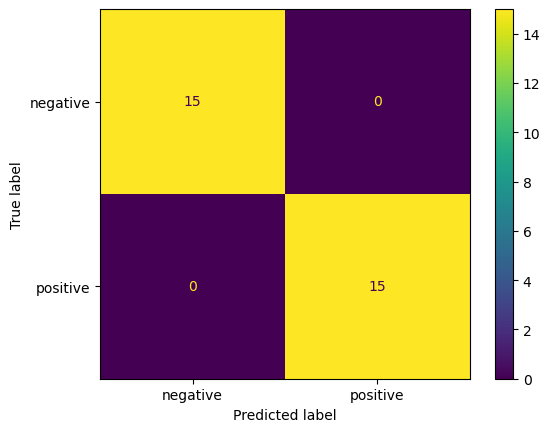

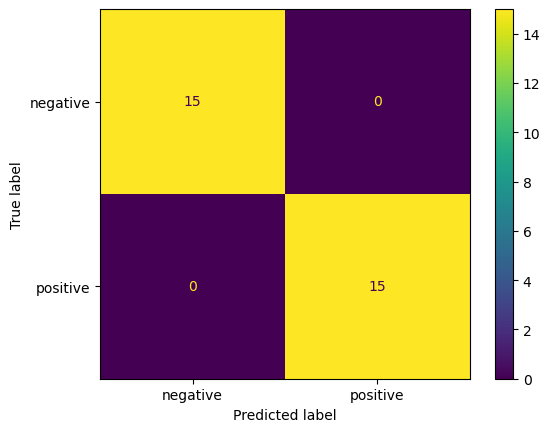

In [4]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

nb_bow = MultinomialNB()

#BOW BASELINE
nb_bow.fit(X_train_bow, y_train)
y_pred_bow = nb_bow.predict(X_test_bow)

print(f"Accuracy: {accuracy_score(y_test, y_pred_bow):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bow))
print("\nClassification Report")
print(classification_report(y_test, y_pred_bow))

#TFIDF BASELINE

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf,y_train)
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred_tfidf)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tfidf))
print("\nClassification report:")
print(classification_report(y_test, y_pred_tfidf))
print("\nLabeled Confusion Matrix")
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bow))
print()
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tfidf))

5
Accuracy: 1.0

Confusion Matrix:
[[15  0]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Labeled Confusion Matrix
Accuracy: 1.0

Confusion Matrix:
[[15  0]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Labeled Confusion Matrix


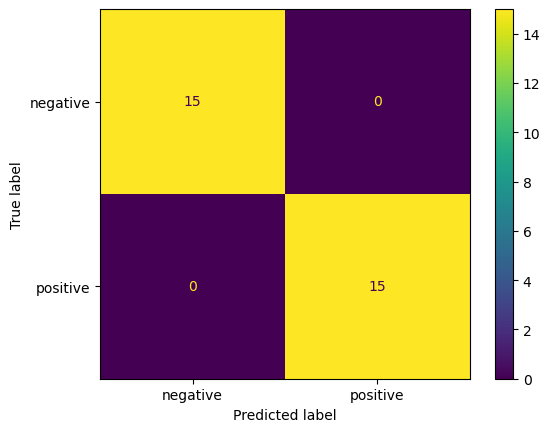

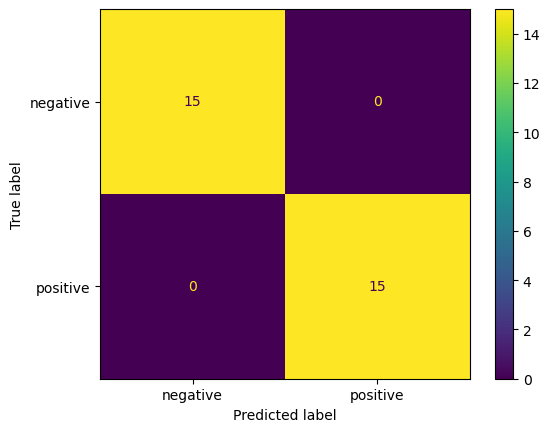

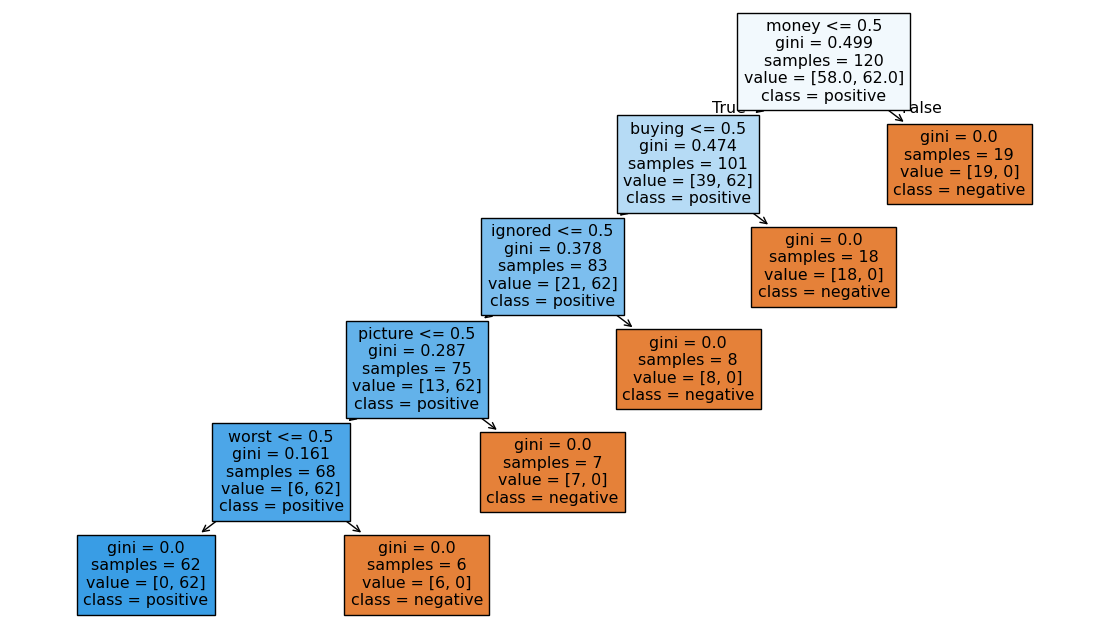

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# BOW
tree_bow = DecisionTreeClassifier(random_state=42)

tree_bow.fit(X_train_bow, y_train)
y_pred_tree= tree_bow.predict(X_test_bow)

print(tree_bow.get_depth())
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nClassification report:")
print(classification_report(y_test, y_pred_tree))
print("\nLabeled Confusion Matrix")
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree))

# TFIDF
tree_tfidf = DecisionTreeClassifier(random_state=42)

tree_tfidf.fit(X_train_tfidf, y_train)
y_pred_tree_tfidf = tree_tfidf.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree_tfidf)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree_tfidf))
print("\nClassification report:")
print(classification_report(y_test, y_pred_tree_tfidf))
print("\nLabeled Confusion Matrix")
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree_tfidf))


# Visual Display
plt.figure(figsize=(14,8))
plot_tree(
    tree_bow,
    feature_names=bow.get_feature_names_out(),
    class_names=tree_bow.classes_,
    filled=True
)
plt.show()


Accuracy: 1.0

Confusion Matrix:
[[15  0]
 [ 0 15]]

Classification report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        15
    positive       1.00      1.00      1.00        15

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Labeled Confusion Matrix
Most negative: ['nothing' 'disappointed' 'picture' 'like' 'material']
Most positive: ['quick' 'fantastic' 'happy' 'amazing' 'family']


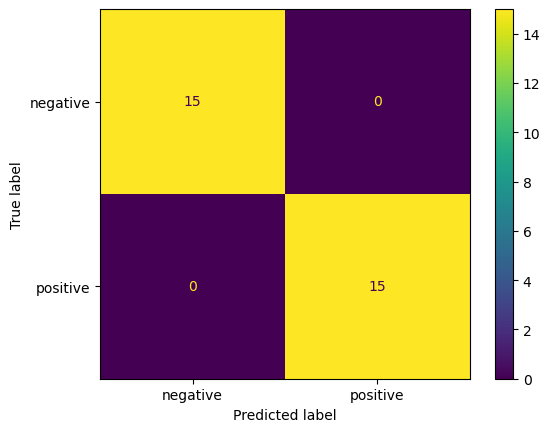

In [11]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# BoW Logistic
logreg_bow = LogisticRegression()

logreg_bow.fit(X_train_bow, y_train)
y_pred_logbow = logreg_bow.predict(X_test_bow)

print(f"Accuracy: {accuracy_score(y_test, y_pred_logbow)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logbow))
print("\nClassification report:")
print(classification_report(y_test, y_pred_logbow))
print("\nLabeled Confusion Matrix")
print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logbow))

words = bow.get_feature_names_out()
weights = logreg_bow.coef_[0]

order = np.argsort(weights)
print("Most negative:", words[order[:5]])
print("Most positive:", words[order[-5:]])